# Waste Classification using Image clustering

DATA COLLECTION

In [ ]:
from google.colab import drive    # connect a google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!ls "/content/drive/MyDrive/Dataset"

'Waste classfication dataset.zip'


In [ ]:
!unzip "/content/drive/MyDrive/Dataset/Waste classfication dataset.zip" -d "/content/waste_dataset"

Archive:  /content/drive/MyDrive/Dataset/Waste classfication dataset.zip
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_1.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_10.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_100.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_101.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_102.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_103.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_104.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_105.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_106.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_107.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_108.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_109.jpg  
  inflating: /content/waste_dataset/1-Cardboard/Cardboard_11.jpg  
  inflating: /content/waste_dataset/1-Cardboard

EDA (BASIC)

In [ ]:
import os
path = "/content/waste_dataset"
os.listdir(path)

['6-Paper',
 '4-Metal',
 '7-Plastic',
 '2-Food Organics',
 '9-Vegetation',
 '3-Glass',
 '8-Textile Trash',
 '5-Miscellaneous Trash',
 '1-Cardboard']

In [ ]:
for c in os.listdir(path):
    class_path = os.path.join(path, c)

    print(c, len(os.listdir(class_path)))

6-Paper 500
4-Metal 790
7-Plastic 921
2-Food Organics 411
9-Vegetation 436
3-Glass 420
8-Textile Trash 318
5-Miscellaneous Trash 495
1-Cardboard 461


DATA VISUALIZATION

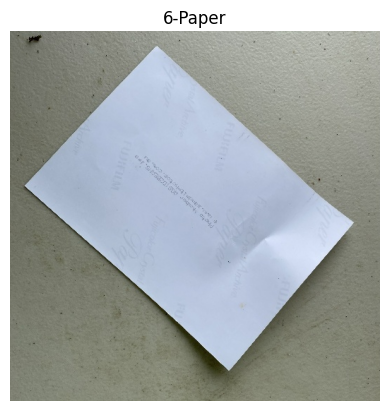

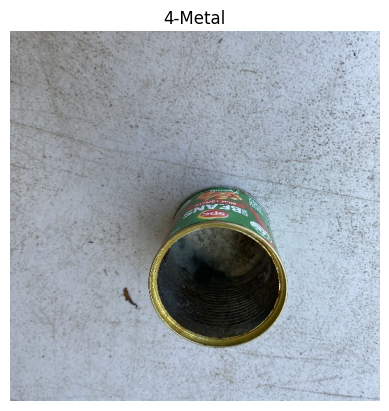

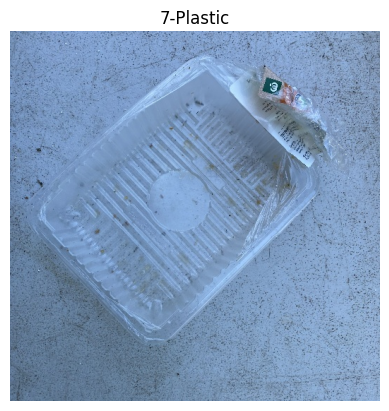

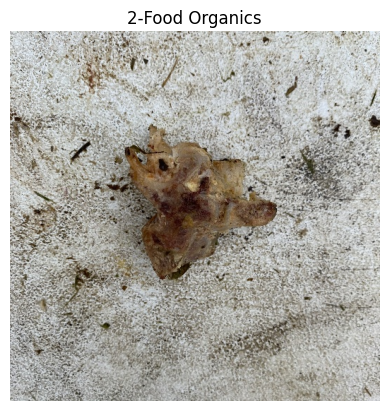

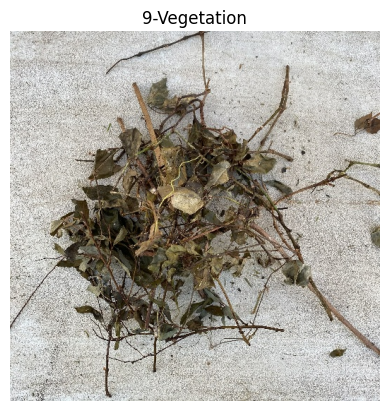

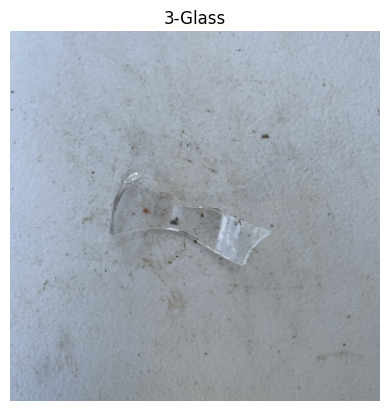

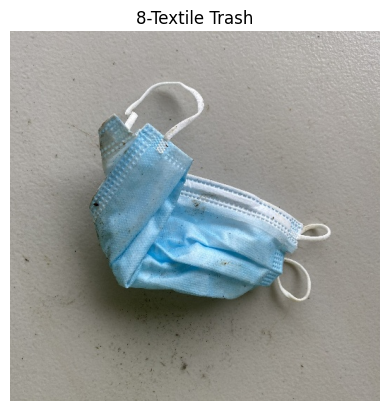

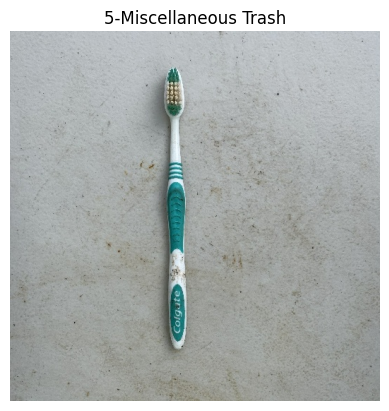

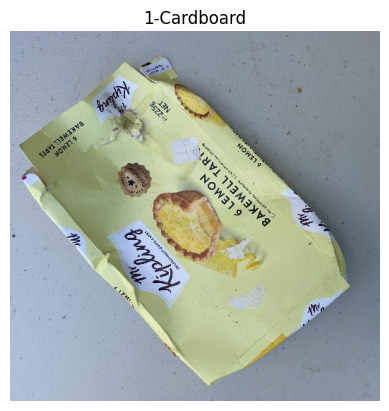

In [ ]:
import matplotlib.pyplot as plt
import cv2

for c in os.listdir(path):
    class_path = os.path.join(path, c)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')

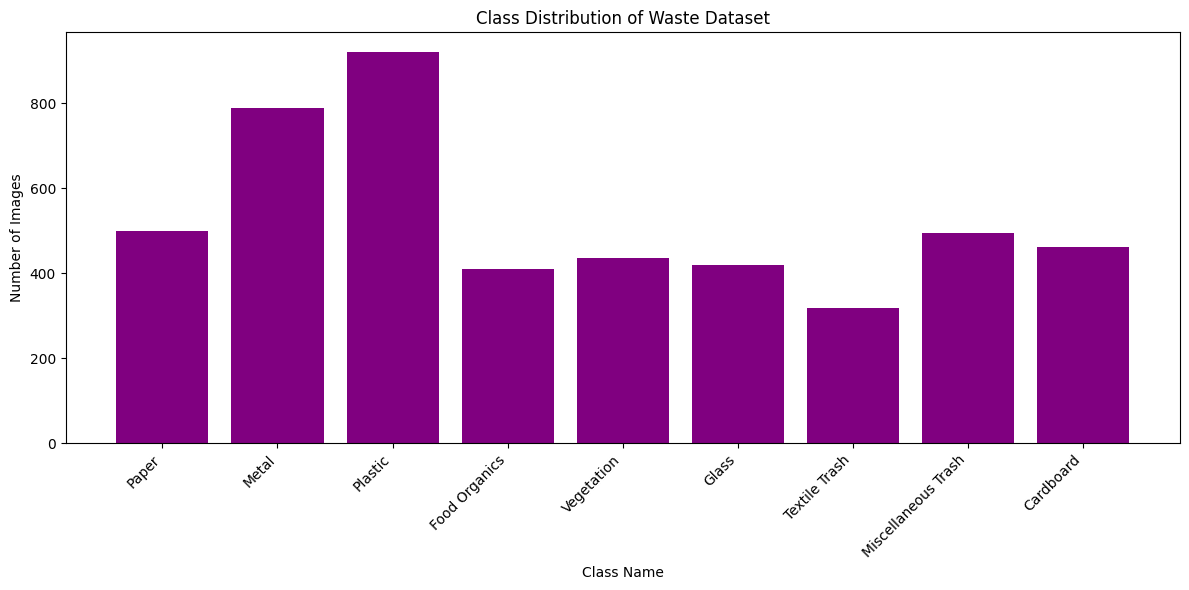

In [ ]:
class_names = []
image_counts = []

for c in os.listdir(path):
    class_path = os.path.join(path, c)
    if os.path.isdir(class_path):
        class_names.append(c)
        image_counts.append(len(os.listdir(class_path)))

# Clean class names (optional, remove numbering)
class_names = [c.split('-')[-1] for c in class_names]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(class_names, image_counts, color='purple')
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Waste Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Class Distribution Bar Chart show clear count of each class.

PRE-PROCESSING

In [ ]:
# import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [ ]:
#Define Dataset Path
DATASET_PATH = "/content/waste_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
#Data Augmentation + Normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
#Training Data Generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 3803 images belonging to 9 classes.


In [ ]:
#Validation Data Generator
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 949 images belonging to 9 classes.


In [ ]:
# Verify Class Labels
print(train_generator.class_indices)

{'1-Cardboard': 0, '2-Food Organics': 1, '3-Glass': 2, '4-Metal': 3, '5-Miscellaneous Trash': 4, '6-Paper': 5, '7-Plastic': 6, '8-Textile Trash': 7, '9-Vegetation': 8}


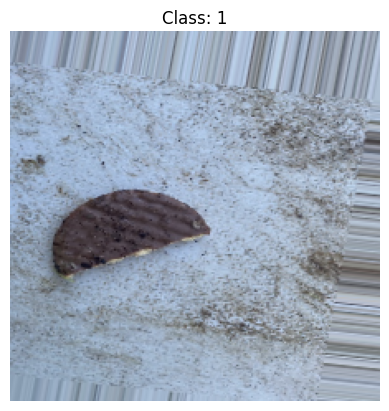

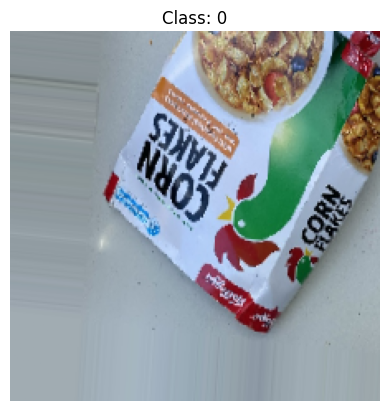

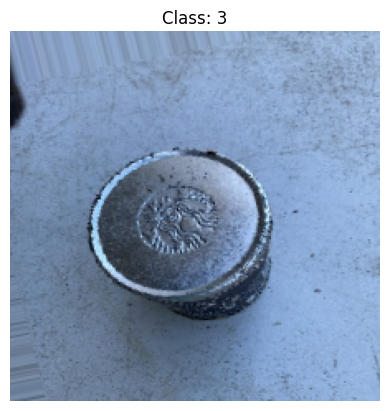

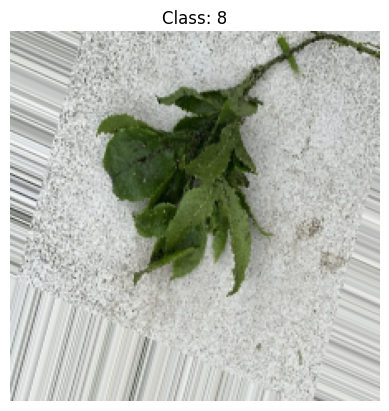

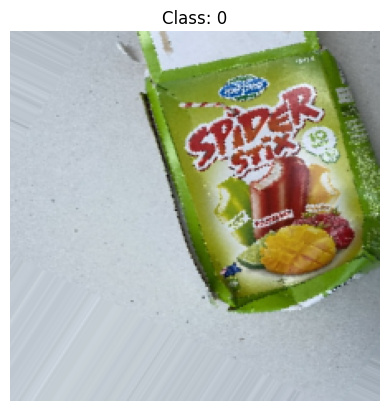

In [ ]:
#Visualize Augmented Images
import matplotlib.pyplot as plt
import numpy as np

x_batch, y_batch = next(train_generator)

for i in range(5):
    plt.imshow(x_batch[i])
    plt.title(f"Class: {np.argmax(y_batch[i])}")
    plt.axis("off")
    plt.show()

FEATURE EXTRRACTION

In [ ]:
#Import Required Libraries for Feature Extraction
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
import numpy as np

In [ ]:
#Load Pretrained CNN (Without Classification Head)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Add Global Pooling Layer
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs=base_model.input, outputs=x)

In [ ]:
#Freeze CNN Layers
#changes made, last 40 layers unfreezed
for layer in feature_extractor.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
  layer.trainable = True

In [ ]:
#Extract Features from Dataset
def extract_features(generator, model):
    features = []
    labels = []
    filenames = []

    generator.reset()

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feature_batch = model.predict(x_batch, verbose=0)

        features.append(feature_batch)
        labels.append(np.argmax(y_batch, axis=1))
        filenames.extend(generator.filenames[i * generator.batch_size:
                                              (i + 1) * generator.batch_size])

    return np.vstack(features), np.hstack(labels), filenames

In [ ]:
#Run Feature Extraction
features, labels, image_paths = extract_features(train_generator, feature_extractor)

In [ ]:
#Verify Feature Shape
print("Feature shape:", features.shape)
print("Labels shape:", labels.shape)

Feature shape: (3803, 1280)
Labels shape: (3803,)


In [ ]:
#change made, adding PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=10)
features_pca = pca.fit_transform(features)

print("Original:", features.shape)
print("After PCA:", features_pca.shape)

Original: (3803, 1280)
After PCA: (3803, 10)


In [ ]:
#Save Extracted Features
np.save("features.npy", features_pca)
np.save("labels.npy", labels)
np.save("image_paths.npy", image_paths)

FEATURE SCALING

In [ ]:
#Import Scaler
from sklearn.preprocessing import StandardScaler

In [ ]:
#Initialize the Scaler
scaler = StandardScaler()

In [ ]:
#Fit and Transform Features
#change made. scalaing pca features. not raw features
features_scaled = scaler.fit_transform(features_pca)

In [ ]:
#Verify Scaling (Optional but Good Practice)
print("Mean (approx):", features_scaled.mean())
print("Std (approx):", features_scaled.std())

Mean (approx): -3.0092273e-09
Std (approx): 0.99999994


In [ ]:
#Save Scaled Features
np.save("features_scaled.npy", features_scaled)

IMAGE CLUSTERING (K-Means)

In [ ]:
#IMPORT REQUIRED LIBRARIES
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

In [ ]:
#DECIDE NUMBER OF CLUSTERS (K)
num_clusters = len(train_generator.class_indices)

In [ ]:
#APPLY K-MEANS CLUSTERING
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=20 #incresed from 10 to 20
)

cluster_labels = kmeans.fit_predict(features_scaled)

In [ ]:
#CHECK OUTPUT SHAPE
print(cluster_labels.shape)

(3803,)


CLUSTER QUALITY EVALUATION

In [ ]:
#Silhouette Score
sil_score = silhouette_score(features_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.14902121


In [ ]:

#Davies–Bouldin Index
db_score = davies_bouldin_score(features_scaled, cluster_labels)
print("Davies-Bouldin Score:", db_score)

#score is the lowest at pca 10 in comparision to PCA being 20,30 or 40. thus 10 is the best in practicality

Davies-Bouldin Score: 1.7126502140182893


PCA components = 10 turns out to be the best choice for our model

ADDING IMAGE CLASSIFICATION MODEL

In [ ]:
from tensorflow.keras import layers, models, callbacks

In [ ]:
num_classes = len(train_generator.class_indices)

In [ ]:
#Base CNN same as before
base_model = MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False #staring with frozen layers

In [ ]:
#Classification head

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes,activation= 'softmax')(x)
model = models.Model(inputs=base_model.input, outputs = outputs)

In [ ]:
#compiling model

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = 'categorical_crossentropy',
    metrics= ['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,593,353 (9.89 MB)

 Trainable params: 332,809 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Training

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [ ]:
checkpoint = callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor = 'val_accuracy',
    save_best_only = True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 20,
    callbacks = [early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1927 - loss: 2.7884

119/119 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.1935 - loss: 2.7844 - val_accuracy: 0.4742 - val_loss: 1.5370
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4900 - loss: 1.5551

119/119 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.4901 - loss: 1.5546 - val_accuracy: 0.5627 - val_loss: 1.3260
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5790 - loss: 1.2932

119/119 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.5790 - loss: 1.2928 - val_accuracy: 0.5774 - val_loss: 1.2558
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6186 - loss: 1.1079

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.7369 - loss: 0.7698 - val_accuracy: 0.6333 - val_loss: 1.1298
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7254 - loss: 0.7675 - val_accuracy: 0.6196 - val_loss: 1.1561
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7543 - loss: 0.7037

119/119 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.7543 - loss: 0.7038 - val_accuracy: 0.6365 - val_loss: 1.0772
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7552 - loss: 0.6982

119/119 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.7551 - loss: 0.6983 - val_accuracy: 0.6502 - val_loss: 1.0669
Epoch 13/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.7778 - loss: 0.6217 - val_accuracy: 0.6428 - val_loss: 1.0906
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7761 - loss: 0.6311

119/119 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.7761 - loss: 0.6312 - val_accuracy: 0.6575 - val_loss: 1.0495
Epoch 15/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.7678 - loss: 0.6357 - val_accuracy: 0.6575 - val_loss: 1.0324
Epoch 16/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.8087 - loss: 0.5648 - val_accuracy: 0.6459 - val_loss: 1.0413
Epoch 17/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.7923 - loss: 0.5654 - val_accuracy: 0.6491 - val_loss: 1.0958
Epoch 18/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.7977 - loss: 0.5725 - val_accuracy: 0.6459 - val_loss: 1.0800
Epoch 19/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.8007 - loss: 0.5419 - val_accuracy: 0.6502 - val_loss: 1.0602
Epoch 20/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8130 - loss: 0.5471

119/119 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.8130 - loss: 0.5470 - val_accuracy: 0.6596 - val_loss: 1.0267


Evaluation ( Accuracy, Loss, Confusion matrix)

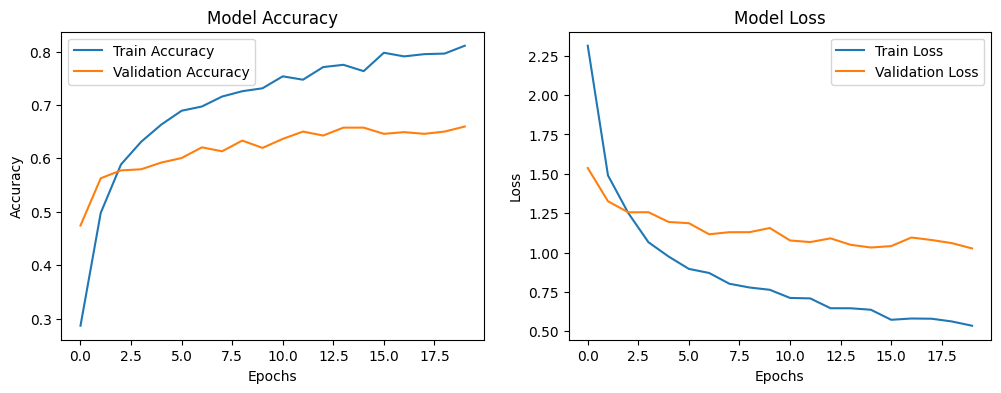

In [ ]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#loss plot

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()



Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

30/30 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step


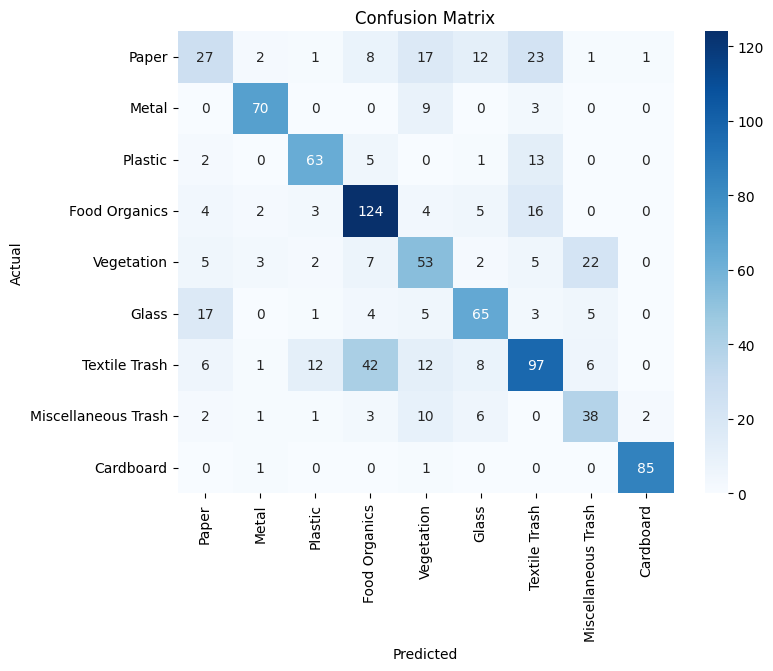

                     precision    recall  f1-score   support

              Paper       0.43      0.29      0.35        92
              Metal       0.88      0.85      0.86        82
            Plastic       0.76      0.75      0.75        84
      Food Organics       0.64      0.78      0.71       158
         Vegetation       0.48      0.54      0.50        99
              Glass       0.66      0.65      0.65       100
      Textile Trash       0.61      0.53      0.56       184
Miscellaneous Trash       0.53      0.60      0.56        63
          Cardboard       0.97      0.98      0.97        87

           accuracy                           0.66       949
          macro avg       0.66      0.66      0.66       949
       weighted avg       0.65      0.66      0.65       949



In [ ]:
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis = 1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt = 'd',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
model.save("Waste_classification_model.keras")

In [ ]:
def predict_image(img_path, model):
  img = tf.keras.preprocessing.image.load_img(
      img_path, target_size=(224,224)
  )
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  img_array = img_array / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  preds = model.predict(img_array)
  class_idx = np.argmax(preds)
  return class_names[class_idx]


Image upload and prediction using collab

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("best_model.h5")

In [ ]:
#To upload image
from google.colab import files

upload = files.upload()

Saving waste2.jfif to waste2 (2).jfif


preprocessing image

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

def preprocess_image(img_path):
  img = cv2.imread(img_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img = cv2.resize(img, (224, 224))
  img = img/255.0
  img = np.expand_dims(img, axis = 0)
  return img

predicting the class of waste

In [ ]:
#getting uploaded image
image_path = list(upload.keys())[0]

#preprocessing the uploaded image
processed_img = preprocess_image(image_path)


#predicting the class of uploaded image
predictions = model.predict(processed_img)
predicted_class = np.argmax(predictions )

#mapping class label
class_labels = {v:k for k, v in train_generator.class_indices.items()}

print("Predicted class is ", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted class is  4-Metal


In [ ]:
#Filter to prdict if the waste is recyclable
recyclable = {
    "4-Metal": "Recyclable",
    "3-Glass": "Recyclable",
    "7-Plastic":"Recyclable",
    "6-Paper": "Recyclable",
    "1-Cardboard": "Recyclable",
    "9-Vegetation": "Biodegradable",
    "2-Food Organics": "Non=Recyclable",
    "8-Textile Trash": "Non-recyclable",
    "5-Miscellaneous Trash": "Non-Recyclable"

}

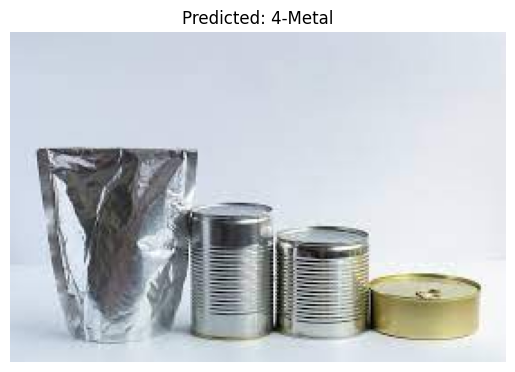

Predicted class: 4-Metal
Recyclability: Recyclable


In [ ]:
#output prediction
import matplotlib.pyplot as plt

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]}")
plt.show()

predicted_label = class_labels[predicted_class]

# Get recyclability status
recyclability = recyclable.get(predicted_label)

print("Predicted class:", predicted_label)
print("Recyclability:", recyclability)


In [ ]:
model.save("best_model.h5")


In [ ]:
import pickle

class_names = list(train_generator.class_indices.keys())

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)


print(class_names)


['1-Cardboard', '2-Food Organics', '3-Glass', '4-Metal', '5-Miscellaneous Trash', '6-Paper', '7-Plastic', '8-Textile Trash', '9-Vegetation']


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")
print("✅ Trained model loaded successfully")


✅ Trained model loaded successfully


In [ ]:
model.evaluate(val_generator)


30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6117 - loss: 1.3191


[1.0131878852844238, 0.6838777661323547]

In [ ]:
model.predict(processed_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


array([[9.68969941e-01, 4.48811101e-03, 3.43136722e-04, 1.18257478e-03,
        6.05696021e-03, 1.34563055e-02, 3.87838081e-04, 4.98884032e-03,
        1.26262807e-04]], dtype=float32)

In [ ]:
model = tf.keras.models.load_model("best_model.h5")
